In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load data
df = pd.read_csv('Fraud.csv')

### 1. Feature Correlation Analysis
Addressing the main issue: Checking how each variable correlates with 'isFraud'.

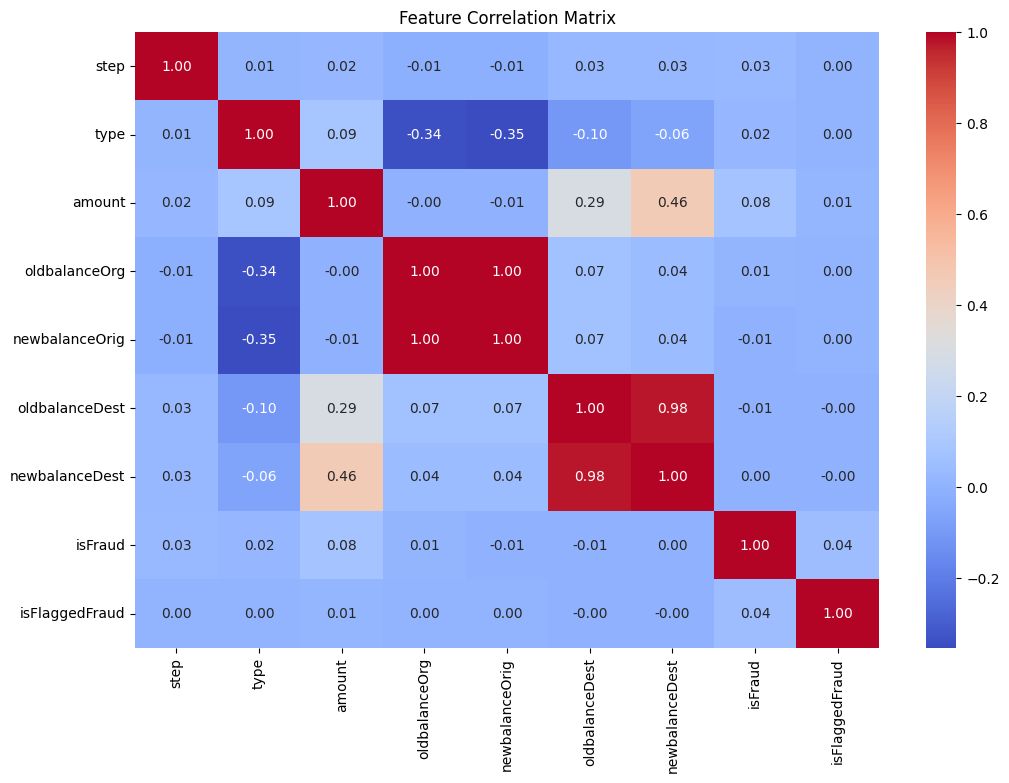

Correlation with Fraud:
isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
type              0.020833
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


In [75]:
# Pre-processing for Correlation (encoding 'type')
le = LabelEncoder()
df_corr = df.copy()
df_corr['type'] = le.fit_transform(df_corr['type'])

# Calculating Correlation
corr = df_corr.select_dtypes(include=[np.number]).corr()

# Visualizing Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

print("Correlation with Fraud:")
print(corr['isFraud'].sort_values(ascending=False))

### 2. Data Cleaning & Feature Selection

In [76]:
# Dropping irrelevant columns
df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1, inplace=True)

# Encoding categorical 'type'
df['type'] = le.fit_transform(df['type'])

### 3. Model Training (Fixing Bias with Balanced Weights)

In [77]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Decision Tree with class_weight='balanced' to remove bias
model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9996911649603465

Confusion Matrix:
 [[1270745     159]
 [    234    1386]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.90      0.86      0.88      1620

    accuracy                           1.00   1272524
   macro avg       0.95      0.93      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

